In [120]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib as plt

In [121]:
df = pd.read_csv(r"HR-Employee-Attrition Raw_Data.csv")

In [122]:
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [123]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [145]:
df["YearsInCurrentRole"].unique()

array([ 4,  7,  0,  2,  5,  9,  8,  3,  6, 13,  1, 15, 14, 16, 11, 10, 12,
       18, 17])

In [125]:
df["EmployeeCount"].unique()
df = df.drop(["EmployeeCount","Over18","StandardHours","EmployeeNumber", "DailyRate","HourlyRate","MonthlyRate"], axis=1)


In [126]:
df["JobInvolvement"]

0       3
1       2
2       2
3       3
4       3
       ..
1465    4
1466    2
1467    4
1468    2
1469    4
Name: JobInvolvement, Length: 1470, dtype: int64

In [127]:
df.columns

Index(['Age', 'Attrition', 'BusinessTravel', 'Department', 'DistanceFromHome',
       'Education', 'EducationField', 'EnvironmentSatisfaction', 'Gender',
       'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction',
       'MaritalStatus', 'MonthlyIncome', 'NumCompaniesWorked', 'OverTime',
       'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction',
       'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear',
       'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole',
       'YearsSinceLastPromotion', 'YearsWithCurrManager'],
      dtype='object')

In [132]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

cat_cols = df.select_dtypes(exclude = ['int64', 'float64']).columns


In [133]:
df["PerformanceRating"].value_counts()

PerformanceRating
3    1244
4     226
Name: count, dtype: int64

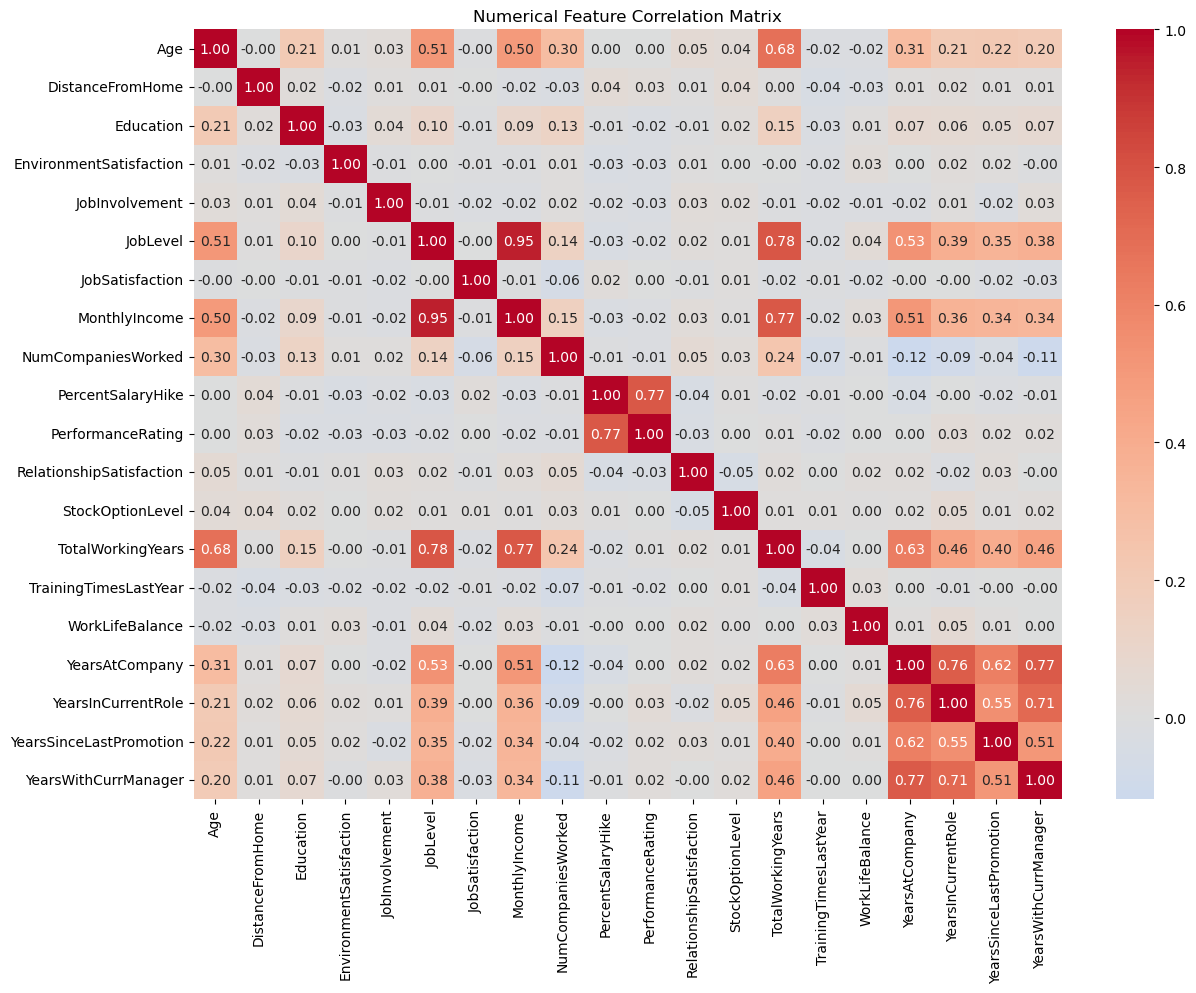

In [134]:
import seaborn as sns
import matplotlib.pyplot as plt

corr_matrix = df[num_cols].corr(method='pearson')

plt.figure(figsize=(14,10))
sns.heatmap(corr_matrix,
            annot=True,
            fmt='.2f',
            cmap='coolwarm',
            center=0)
plt.title('Numerical Feature Correlation Matrix')
plt.show()

In [135]:
corr_pairs = (
    corr_matrix.abs()
    .unstack()
    .sort_values(ascending=False)
)

corr_pairs = corr_pairs[corr_pairs < 1]
print(corr_pairs.head(20))


MonthlyIncome            JobLevel                   0.950300
JobLevel                 MonthlyIncome              0.950300
                         TotalWorkingYears          0.782208
TotalWorkingYears        JobLevel                   0.782208
PerformanceRating        PercentSalaryHike          0.773550
PercentSalaryHike        PerformanceRating          0.773550
MonthlyIncome            TotalWorkingYears          0.772893
TotalWorkingYears        MonthlyIncome              0.772893
YearsAtCompany           YearsWithCurrManager       0.769212
YearsWithCurrManager     YearsAtCompany             0.769212
YearsInCurrentRole       YearsAtCompany             0.758754
YearsAtCompany           YearsInCurrentRole         0.758754
YearsInCurrentRole       YearsWithCurrManager       0.714365
YearsWithCurrManager     YearsInCurrentRole         0.714365
TotalWorkingYears        Age                        0.680381
Age                      TotalWorkingYears          0.680381
YearsAtCompany          

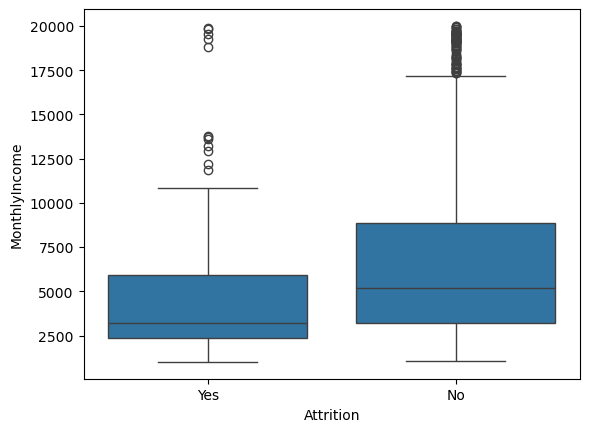

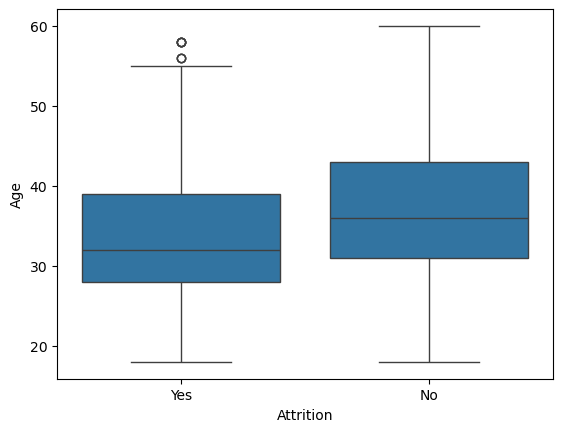

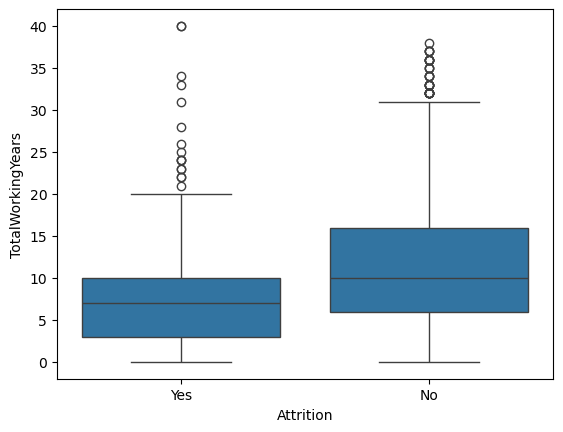

In [137]:
sns.boxplot(
    data=df,
    x='Attrition',
    y='MonthlyIncome'
)
plt.show()

sns.boxplot(
    data=df,
    x='Attrition',
    y='Age'
)
plt.show()

sns.boxplot(
    data=df,
    x='Attrition',
    y='TotalWorkingYears'
)
plt.show()

In [146]:
labels =["Asscociate", "Mid_level","Senior", "Principa"]
df["experience_band"] = pd.qcut(df["YearsInCurrentRole"],q=4, labels=labels)

    

In [148]:
df["experience_band"].nunique

<bound method IndexOpsMixin.nunique of 0           Senior
1           Senior
2       Asscociate
3           Senior
4       Asscociate
           ...    
1465    Asscociate
1466        Senior
1467    Asscociate
1468        Senior
1469     Mid_level
Name: experience_band, Length: 1470, dtype: category
Categories (4, object): ['Asscociate' < 'Mid_level' < 'Senior' < 'Principa']>

In [157]:
df.columns = df.columns.str.lower().str.replace(" ","_")

df.columns
df = df.rename(columns={
    
    'age': 'age',
    'attrition': 'attrition',
    'businesstravel': 'business_travel',
    'department': 'department',
    'distancefromhome': 'distance_from_home',
    'education': 'education',
    'educationfield': 'education_field',
    'environmentsatisfaction': 'environment_satisfaction',
    'gender': 'gender',
    'jobinvolvement': 'job_involvement',
    'joblevel': 'job_level',
    'jobrole': 'job_role',
    'jobsatisfaction': 'job_satisfaction',
    'maritalstatus': 'marital_status',
    'monthlyincome': 'monthly_income',
    'numcompaniesworked': 'num_companies_worked',
    'overtime': 'over_time',
    'percentsalaryhike': 'percent_salary_hike',
    'performancerating': 'performance_rating',
    'relationshipsatisfaction': 'relationship_satisfaction',
    'stockoptionlevel': 'stock_option_level',
    'totalworkingyears': 'total_working_years',
    'trainingtimeslastyear': 'training_times_last_year',
    'worklifebalance': 'work_life_balance',
    'yearsatcompany': 'years_at_company',
    'yearsincurrentrole': 'years_in_current_role',
    'yearssincelastpromotion': 'years_since_last_promotion',
    'yearswithcurrmanager': 'years_with_curr_manager',
    'attrition_binary': 'attrition_binary',
    'experience_band': 'experience_band'


})


In [158]:
df.columns

Index(['age', 'attrition', 'business_travel', 'department',
       'distance_from_home', 'education', 'education_field',
       'environment_satisfaction', 'gender', 'job_involvement', 'job_level',
       'job_role', 'job_satisfaction', 'marital_status', 'monthly_income',
       'num_companies_worked', 'over_time', 'percent_salary_hike',
       'performance_rating', 'relationship_satisfaction', 'stock_option_level',
       'total_working_years', 'training_times_last_year', 'work_life_balance',
       'years_at_company', 'years_in_current_role',
       'years_since_last_promotion', 'years_with_curr_manager',
       'attrition_binary', 'experience_band'],
      dtype='object')

In [159]:
df.head()

,age,attrition,business_travel,department,distance_from_home,education,education_field,environment_satisfaction,gender,job_involvement,...,stock_option_level,total_working_years,training_times_last_year,work_life_balance,years_at_company,years_in_current_role,years_since_last_promotion,years_with_curr_manager,attrition_binary,experience_band
0,41,Yes,Travel_Rarely,Sales,1,2,Life Sciences,2,Female,3,...,0,8,0,1,6,4,0,5,1,Senior
1,49,No,Travel_Frequently,Research & Development,8,1,Life Sciences,3,Male,2,...,1,10,3,3,10,7,1,7,0,Senior
2,37,Yes,Travel_Rarely,Research & Development,2,2,Other,4,Male,2,...,0,7,3,3,0,0,0,0,1,Asscociate
3,33,No,Travel_Frequently,Research & Development,3,4,Life Sciences,4,Female,3,...,0,8,3,3,8,7,3,0,0,Senior
4,27,No,Travel_Rarely,Research & Development,2,1,Medical,1,Male,3,...,1,6,3,3,2,2,2,2,0,Asscociate


In [138]:
!pip install pymysql sqlalchemy pandas


In [160]:
from sqlalchemy import create_engine
from urllib.parse import quote_plus

username = "root"
password = quote_plus("Kittu@123")
host = "localhost"
port = "3306"
database = "hrattrition"

engine = create_engine(f"mysql+pymysql://{username}:{password}@{host}:{port}/{database}")
df.to_sql("hr_attrition", engine, if_exists="replace", index=False)

1470

In [144]:
df.to_csv("HR_Attrition_cleaned.csv", index=False)